In [1]:
import warnings
warnings.filterwarnings("ignore")

# Sales Performance Dashboard

The dashboard is made to analyze the *sales performance* of a **specialty cookie company** operating across multiple internaltional markets. The company makes *6 different types of cookies* and has a market spanning across **Asia, Europe** and **North America**.

The business period the dataset covers is from **August, 2019 to November, 2020**. Total revenue is observed at the *last date of each month*. The timespan captures **457 days** of operational data during a time that includes *normal business operations and the COVID-19 pandemic impact*.

## Tasks and Challenges

1. **Task:**

- Understand which markets (India, Malaysia, Philippines, United Kingdom, United States) are driving profitability and which require strategic intervention.
- Identifying which products (Chocolate Chip, Fortune Cookie, Oatmeal Raisin, Snickerdoodle, Sugar, White Chocolate Macadamia Nut) generate the highest margins and volumes
- Analyze profit margin for improvement opportunities
- Analyze how external factors (like COVID-19) affected sales performance

2. **Challenges:**

- Lack of standardized metrics to compare performance across different geographical regions
- Understanding demand patterns to optimize production and stock levels
- Optimization of total operational cost of $3.40M.
- Understanding sales fluctuations throughout the business cycle and detecting growth or decline patterns across different time periods

## Business Objectives:

A) ***Primary Objectives:***
1. *Sales Performance Optimization:* Identify top-performing markets and products to focus resources
effectively
2. *Profitability Enhancement:* Analyze cost structures and profit margins to improve overall financial
performance
3. *Market Expansion Strategy:* Determine which markets and products offer the best growth opportunities
4. *Operational Efficiency:* Optimize inventory and production based on demand patterns

B) ***Secondary Objectives:***
1. *Risk Management:* Identify underperforming segments that may require intervention
2. *Strategic Planning:* Provide data-driven insights for future business decisions
3. *Performance Benchmarking:* Establish KPIs and benchmarks for ongoing performance monitoring
4. *Competitive Positioning:* Understand market positioning based on sales volume and profitability

## Data Characteristics

| Column Name |              Description                |
|-------------|-----------------------------------------|
|     Date    |          The last date of the month     |
|   Country   |          The region of market           |
|   Product   |           The cookie type sold          |
| Units Sold  |  Total quantity of items sold that month|
|   Revenue   |  Total Revenue generated from the sale  |
|     Cost    |      Total cost price of item sold      |
|    Profit   |      Total profit made from item sold   |

1. **Dataset Overview:**
- Time Period: September 2019 - December 2020 (457 days)
- Transaction Volume: 1,225 total transactions
- Geographic Coverage: 5 countries across 3 continents
- Product Range: 6 specialty cookie varieties
- Financial Scope: ( in dollars $) 8.28M revenue, 4.88M profit, 3.40M costs (in raw data)

2. **Key Metrics:**

- Revenue Performance: (in raw data) $8,277,489 total revenue
- Profit Margin: (in raw data) 58.92% overall profit margin
- Volume Metrics: (in raw data) 1,986,974 units sold
- Transparency Efficiency: (in raw data) Average 1,622 units sold
- Market Penetration: Operations across 5 international markets

In [2]:
# Importing Necessary Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf

In [4]:
class DataLoader:
    def __init__(self):
        pass

    def load_data(self, input_data: str = None):
        try:
            data = pd.read_csv(filepath_or_buffer = input_data, delimiter = ',')
            return data

        except FileNotFoundError as e:
            raise ValueError(f"Could not find the file you were looking for : {e}")

In [5]:
class DataInspection:
    def __init__(self, input_data: str = None):
        try:
            self.input_data  = input_data
        except FileNotFoundError as e:
            print(f"No file found: {e}")

    def data_description(self):
        return self.input_data.describe()

    def data_info(self):
        return self.input_data.info()

    def col_names(self):
        return self.input_data.columns

    def data_shape(self):
        return self.input_data.shape

    def find_null(self):
        missing = self.input_data.isnull().sum()
        missing_percent = (missing / len(self.input_data)) * 100
        return pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})

    def change_date_format(self):
        self.input_data['Date'] = (pd.to_datetime(self.input_data['Date'], 
                                                 origin  ='1900-01-01', 
                                                 unit    ='D') - pd.Timedelta(days = 2)).dt.strftime("%Y-%m-%d")
        return self.input_data

    def sort_data(self):
        # Convert 'Date' column to datetime
        self.input_data['Date'] = pd.to_datetime(self.input_data['Date'], format="%Y-%m-%d")
    
        # Sort the entire DataFrame by date
        self.input_data = self.input_data.sort_values(by='Date').reset_index(drop=True)
    
        return self.input_data

    def find_duplicate(self):
        return self.input_data.duplicated().sum()

    def remove_duplicates(self):
        self.input_data =  self.input_data.drop_duplicates()
        return self.input_data

    def check_outliers(self, column_name: str = None, z_thresh=3):
        try:
            z_scores = (self.input_data[column_name] - self.input_data[column_name].mean()) / self.input_data[column_name].std()
            outliers = self.input_data[np.abs(z_scores) > z_thresh]
            return outliers

        except Exception as e:
            print(f"Unable to detect outliers: {e}")

    def handle_outliers(self, window: int = 2, column_name: str = None):
        if column_name is None:
            raise ValueError("Please provide a column name.")

        # Work on a copy of the column to avoid SettingWithCopyWarning
        series = self.input_data[column_name].copy()

        # Calculate IQR bounds
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # Detect Outliers
        outlier = (series < lower) | (series > upper)

        # Replace each outlier
        for i in range(len(series)):
            if outlier.iloc[i]:
                start = max(0, i - window)
                end = min(len(series), i + window + 1)

                # Get surrounding values and mask
                surrounding = series.iloc[start:end]
                surrounding_mask = outlier.iloc[start:end]
                surrounding = surrounding[~surrounding_mask]

                if not surrounding.empty:
                    series.iloc[i] = int(round(surrounding.mean()))
                else:
                    # Fallback: use global median if all surrounding values are also outliers
                    series.iloc[i] = int(round(series[~outlier].median()))

        # Update only the target column in the original DataFrame
        self.input_data[column_name] = series

        return self.input_data  # Optional: return updated DataFrame

# Exploratory Data Analysis

In [8]:
class ExploratoryDataAnalysis:
    def __init__(self, input_data):
            self.input_data = input_data

    def total_revenue(self):
        return self.input_data['Revenue'].sum()

    def average_revenue(self):
        return self.input_data['Revenue'].mean()

    def profit_margin(self):
        total_profit  = self.input_data['Profit'].sum()
        total_revenue = self.input_data['Revenue'].sum()
        profit_margin = (total_profit / total_revenue) * 100
        return profit_margin

    def total_units(self):
        total_units_sold = self.input_data['Units Sold'].sum()
        return total_units_sold

    def top_3_countries(self):
        grouped = self.input_data.groupby("Country").agg(
            Total_Revenue    = pd.NamedAgg(column  = "Revenue", 
                                           aggfunc = "sum"),
            Total_Profit     = pd.NamedAgg(column  = "Profit", 
                                           aggfunc = "sum"),
            Total_Units_Sold = pd.NamedAgg(column  = "Units Sold", 
                                           aggfunc = "sum")
        ).reset_index()

        # Calculate profit percentage
        grouped["Profit_Percentage"] = (grouped["Total_Profit"] / grouped["Total_Revenue"]) * 100

        # Round for display
        grouped["Profit_Percentage"] = grouped["Profit_Percentage"].round(2)

        # Get top 3 companies by revenue
        top_3 = grouped.sort_values(by        = "Total_Revenue", 
                                    ascending = False).head(3)
        return top_3
    
    def top_3_products(self):
        grouped = self.input_data.groupby("Product").agg(
            total_revenue     = pd.NamedAgg(column  = "Revenue",
                                            aggfunc = "sum"),
            total_profit      = pd.NamedAgg(column  = "Profit",
                                            aggfunc = "sum"),
            total_units_sold  = pd.NamedAgg(column  = "Units Sold",
                                            aggfunc = "sum")
        ).reset_index()

        grouped['profit_percent'] = (grouped['total_profit'] / grouped['total_revenue']) * 100
        grouped['profit_percent'] = grouped['profit_percent'].round(2)

        top_3 = grouped.sort_values(by        = "total_revenue",
                                    ascending = False).head(3)
        return top_3

    def barplot_total_sale_by_column(self, column_name: str = None):
        barplot = px.bar(self.input_data, 
                    x                       = column_name, 
                    y                       = "Revenue",
                    title                   = (f"Total Revenue by {column_name}"),
                    hover_name              = 'Product',
                    hover_data              = ['Units Sold', 'Cost', 'Profit'],
                    color                   = column_name,  
                    color_discrete_sequence = px.colors.qualitative.Pastel,
                    height                  = 400,
                    width                   = 600)
        
        barplot.show()

    def pieplot_for_product_sale(self):
        # Group by products and sum the units sold
        product_units = self.input_data.groupby("Product", as_index = False)["Units Sold"].sum()
        colors = px.colors.qualitative.Pastel
        # Plot pie chart
        piechart = px.pie(product_units, 
                            values                  = 'Units Sold', 
                            names                   = 'Product',
                            title                   = 'Percentage of Products Sold',
                            color_discrete_sequence = colors,
                            height                  = 400,
                            width                   = 600
                            )
        piechart.update_layout(autosize = False)
        piechart.show()

    def groupedbar_product_over_country(self):
        # Plot stacked bar chart
        grouped_bar = px.bar(self.input_data,
                             x                       = 'Country',
                             y                       = 'Units Sold',
                             color                   = 'Product',
                             barmode                 = 'group',
                             title                   = 'Units Sold per Product in Each Country',
                             hover_data              = ['Cost', 'Profit', 'Date'],
                             hover_name              = 'Product',
                             color_discrete_sequence = px.colors.qualitative.Pastel,
                             height                  = 400,
                             width                   = 600)
        grouped_bar.show()

    def sales_trend_per_product(self):
        sales_trend = self.input_data.groupby(["Date", "Product"])["Revenue"].sum().reset_index()
        # Plot
        linechart = px.line(sales_trend,
                            x                       = 'Date',
                            y                       = 'Revenue',
                            color                   = 'Product',
                            hover_name              = 'Product',
                            title                   = 'Sales Trend per Product Over Time',
                            height                  = 400,
                            width                   = 600,
                            text                    = 'Date',
                            markers                 = True,
                            color_discrete_sequence = px.colors.qualitative.Pastel,
                            symbol                  = 'Product')
        linechart.update_traces(mode='lines+markers')
        linechart.show()


    def simple_bubble_plot(self):
        grouped = self.input_data.groupby("Product").agg({
                                    "Revenue": "sum",
                                    "Profit": "sum",
                                    "Units Sold": "sum"
                                }).reset_index()
                                
        bubble_plot = px.scatter(grouped,
                                 x = grouped['Revenue'],
                                 y = grouped['Profit'],
                                 color = 'Product',
                                 size = grouped['Units Sold'],
                                 title = 'Bubble Plot: Revenue vs Profit (Size = Units Sold)',
                                 color_discrete_sequence = px.colors.qualitative.Pastel
                                 )
        bubble_plot.show()

    def heatmap_for_product_profit(self):
        # Heatmap: Profit by Product and Country
        pivot = self.input_data.pivot_table(values  = "Profit", 
                                       index   = "Country", 
                                       columns = "Product", 
                                       aggfunc = "sum")
        heatmap = px.imshow(pivot,
                            text_auto = True,
                            aspect  = 'auto',
                            title = 'Profit by Country and Product',
                            color_continuous_scale=px.colors.sequential.Viridis)

        heatmap.show()

    def decompose_revenue(self):
        self.input_data = self.input_data.groupby('Date')['Revenue'].sum().reset_index()

        # Perform seasonal decomposition
        result = seasonal_decompose(self.input_data['Revenue'], model='additive', period=3)

        # Create a Plotly subplot with 4 rows (original, trend, seasonal, residual)
        decomposition_plot = make_subplots(rows = 4, 
                                           cols = 1, 
                                           shared_xaxes = True,
                                           subplot_titles = ("Original Series", 
                                                             "Trend", 
                                                             "Seasonal", 
                                                             "Residual"))

        # Original series
        decomposition_plot.add_trace(go.Scatter(x    = self.input_data.index, 
                                                y    = self.input_data['Revenue'],
                                                mode = 'lines', 
                                                name = 'Original',
                                                line=dict(color='red')),
                                     row = 1, 
                                     col = 1)

        # Trend
        decomposition_plot.add_trace(go.Scatter(x    = self.input_data.index, 
                                                y    = result.trend,
                                                mode = 'lines', 
                                                name = 'Trend',
                                                line=dict(color='blue')),
                                     row = 2, 
                                     col = 1)

        # Seasonal
        decomposition_plot.add_trace(go.Scatter(x    = self.input_data.index, 
                                                y    = result.seasonal,
                                                mode = 'lines', 
                                                name = 'Seasonal',
                                                line=dict(color='green')),
                                     row = 3, 
                                     col = 1)

        # Residual
        decomposition_plot.add_trace(go.Scatter(x = self.input_data.index, 
                                                y = result.resid,
                                                mode = 'markers', 
                                                name = 'Residual',
                                                marker=dict(color='red')),
                                     row = 4, 
                                     col = 1)

        # Layout settings
        decomposition_plot.update_layout(height = 900, 
                                         width  = 1000,
                                         title_text = "Additive Decomposition of Monthly Revenue (Period = 3)",
                                         showlegend = False)

        decomposition_plot.show()

    def rolling_plot(self, target_col='Revenue', window=30):
        self.input_data['Rolling_Mean'] = self.input_data[target_col].rolling(window).mean()
        self.input_data['Rolling_Std'] = self.input_data[target_col].rolling(window).std()

        melted_df = self.input_data[['Date', target_col, 'Rolling_Mean', 'Rolling_Std']].melt(id_vars='Date')

        fig = px.line(
            melted_df,
            x='Date',
            y='value',
            color='variable',
            title=f"{target_col} with {window}-Day Rolling Mean & Std Dev"
        )
        fig.show()

In [44]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

class ForecastingRiskAnalyzer:
    def __init__(self, df, date_col='Date', target_col='Revenue'):
        self.df = df.copy()
        self.date_col = date_col
        self.target_col = target_col

    def volatility_analysis(self):
        self.df['Change'] = self.df[self.target_col].pct_change()
        volatility = self.df['Change'].std()
        return volatility

    def seasonality_check(self, freq='M'):
        resampled = self.df.set_index(self.date_col).resample(freq)[self.target_col].mean().reset_index()
        fig = px.line(resampled, x=self.date_col, y=self.target_col,
                      title=f"{self.target_col} Seasonality ({freq} Resample)",
                      labels={self.target_col: f"{self.target_col} (mean)", self.date_col: "Date"})
        fig.show()

    def monte_carlo_simulation(self, simulations=500, forecast_days=30):
        last_value = self.df[self.target_col].iloc[-1]
        daily_returns = self.df[self.target_col].pct_change().dropna()
        mu = daily_returns.mean()
        sigma = daily_returns.std()

        simulated_df = pd.DataFrame()

        for i in range(simulations):
            series = [last_value]
            for _ in range(forecast_days):
                shock = np.random.normal(loc=mu, scale=sigma)
                series.append(series[-1] * (1 + shock))
            simulated_df[i] = series

        simulated_df['Day'] = simulated_df.index
        melted = simulated_df.melt(id_vars='Day', var_name='Simulation', value_name='Forecast')

        fig = px.line(melted, x='Day', y='Forecast', color='Simulation',
                      title="Monte Carlo Simulation Forecast",
                      labels={'Day': 'Days Ahead', 'Forecast': self.target_col})
        fig.update_traces(line=dict(width=1), selector=dict(type='scatter'))
        fig.update_layout(showlegend=False)
        fig.show()

    def plot_outliers(self, z_thresh=3):
        z_scores = (self.df[self.target_col] - self.df[self.target_col].mean()) / self.df[self.target_col].std()
        self.df['Outlier'] = np.where(np.abs(z_scores) > z_thresh, 'Outlier', 'Normal')

        fig = px.scatter(self.df, x=self.date_col, y=self.target_col, color='Outlier',
                         title=f"{self.target_col} with Outliers (Z>{z_thresh})",
                         color_discrete_map={'Normal': 'blue', 'Outlier': 'red'})
        fig.show()

    def plot_volatility(self):
        self.df['Change'] = self.df[self.target_col].pct_change()
        fig = px.line(self.df, x=self.date_col, y='Change',
                      title=f"Daily % Change in {self.target_col} (Volatility)",
                      labels={'Change': '% Change'})
        fig.show()

    def risk_summary(self):
        return {
            'Missing Values': self.check_missing_data().to_dict(),
            'Outlier Count': len(self.detect_outliers()),
            'Duplicate Rows': self.check_duplicates(),
            'Volatility (std of % change)': self.volatility_analysis()
        }

    def full_risk_report(self, show_plot=True):
        print("----- Risk Summary -----")
        summary = self.risk_summary()
        for key, val in summary.items():
            print(f"{key}: {val}")

        if show_plot:
            print("\n--- Visual Checks with Plotly ---")
            self.plot_outliers()
            self.plot_volatility()
            self.seasonality_check()
            self.monte_carlo_simulation()

In [6]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import ttest_ind

class CovidImpactAnalyzer:
    def __init__(self, df, date_col='Date', target_col='Revenue',
                 covid_start='2020-03-01', covid_end='2021-12-31'):
        self.df = df.copy()
        self.date_col = date_col
        self.target_col = target_col
        self.covid_start = pd.to_datetime(covid_start)
        self.covid_end = pd.to_datetime(covid_end)
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        self.df.sort_values(by=date_col, inplace=True)

        self.pre_covid = self.df[self.df[date_col] < self.covid_start]
        self.during_covid = self.df[(self.df[date_col] >= self.covid_start) & (self.df[date_col] <= self.covid_end)]
        self.post_covid = self.df[self.df[date_col] > self.covid_end]

    def plot_covid_impact(self):
        fig = px.line(self.df, x=self.date_col, y=self.target_col,
                      title=f"{self.target_col} Trend with COVID Period Highlighted")
        fig.add_vrect(x0=self.covid_start, x1=self.covid_end, 
                      fillcolor="red", opacity=0.3, 
                      layer="below", line_width=0,
                      annotation_text="COVID Period", annotation_position="top left")
        fig.show()

    def compare_periods_boxplot(self):
        self.df['Period'] = self.df[self.date_col].apply(lambda x:
            'Pre-COVID' if x < self.covid_start else (
                'During-COVID' if self.covid_start <= x <= self.covid_end else 'Post-COVID'))

        fig = px.box(self.df, x='Period', y=self.target_col,
                     title=f"{self.target_col} Distribution Across Periods",
                     color='Period')
        fig.show()

    def rolling_mean_compare(self, window=30):
        self.df['Rolling_Mean'] = self.df[self.target_col].rolling(window).mean()
        fig = px.line(self.df, x=self.date_col, y='Rolling_Mean',
                      title=f"{self.target_col} {window}-Day Rolling Mean with COVID Highlight")
        fig.add_vrect(x0=self.covid_start, x1=self.covid_end,
                      fillcolor="red", opacity=0.3,
                      layer="below", line_width=0,
                      annotation_text="COVID Period", annotation_position="top left")
        fig.show()

    def summary_statistics(self):
        return {
            'Pre-COVID Mean': self.pre_covid[self.target_col].mean(),
            'During-COVID Mean': self.during_covid[self.target_col].mean(),
            'Post-COVID Mean': self.post_covid[self.target_col].mean()
        }

    def t_test(self):
        t_stat1, p_val1 = ttest_ind(self.pre_covid[self.target_col], self.during_covid[self.target_col], equal_var=False)
        t_stat2, p_val2 = ttest_ind(self.during_covid[self.target_col], self.post_covid[self.target_col], equal_var=False)
        return {
            "Pre vs During COVID": {"t_statistic": t_stat1, "p_value": p_val1},
            "During vs Post COVID": {"t_statistic": t_stat2, "p_value": p_val2}
        }

    def full_covid_report(self):
        print("----- Summary Statistics -----")
        print(self.summary_statistics())

        print("\n----- T-Test Results -----")
        print(self.t_test())

        print("\n----- Plots -----")
        self.plot_covid_impact()
        self.compare_periods_boxplot()
        self.rolling_mean_compare()


In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet  # Requires: pip install prophet

class ForecastPipeline:
    def __init__(self, df, date_col='Date', target_col='Revenue'):
        self.original_df = df.copy()
        self.date_col = date_col
        self.target_col = target_col
        self.df = df.copy()
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        self.df.sort_values(by=date_col, inplace=True)
        self.df.set_index(date_col, inplace=True)
        self.model = None
        self.forecast_result = None

    def adf_test(self):
        result = adfuller(self.df[self.target_col].dropna())
        return {
            'ADF Statistic': result[0],
            'p-value': result[1],
            'Stationary': result[1] < 0.05
        }

    # ------------------------
    # ARIMA
    # ------------------------
    def train_arima(self, order=(1, 1, 1)):
        self.model = ARIMA(self.df[self.target_col], order=order).fit()
        return self.model.summary()

    def forecast_arima(self, steps=30):
        forecast_values = self.model.forecast(steps=steps)
        forecast_index = pd.date_range(start=self.df.index[-1] + pd.Timedelta(days=1), periods=steps)
        self.forecast_result = pd.Series(forecast_values.values, index=forecast_index)
        return self.forecast_result

    # ------------------------
    # Exponential Smoothing
    # ------------------------
    def train_ets(self, seasonal='add', seasonal_periods=12):
        self.model = ExponentialSmoothing(
            self.df[self.target_col],
            trend='add',
            seasonal=seasonal,
            seasonal_periods=seasonal_periods
        ).fit()
        return self.model.summary()

    def forecast_ets(self, steps=30):
        forecast = self.model.forecast(steps)
        forecast_index = pd.date_range(start=self.df.index[-1] + pd.Timedelta(days=1), periods=steps)
        self.forecast_result = pd.Series(forecast.values, index=forecast_index)
        return self.forecast_result

    # ------------------------
    # Prophet
    # ------------------------
    def train_prophet(self):
        df_prophet = self.original_df[[self.date_col, self.target_col]].rename(columns={self.date_col: 'ds', self.target_col: 'y'})
        self.model = Prophet()
        self.model.fit(df_prophet)

    def forecast_prophet(self, periods=30):
        future = self.model.make_future_dataframe(periods=periods)
        forecast = self.model.predict(future)
        self.forecast_result = forecast[['ds', 'yhat']].set_index('ds').iloc[-periods:]
        return self.forecast_result

    # ------------------------
    # Evaluation & Plotting
    # ------------------------
    def evaluate(self, actual, predicted):
        mae = mean_absolute_error(actual, predicted)
        rmse = mean_squared_error(actual, predicted, squared=False)
        mape = np.mean(np.abs((actual - predicted) / actual)) * 100
        return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

    def plot_forecast(self, model_name="Forecast"):
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=self.df.index, y=self.df[self.target_col],
                                 name="Actual", mode='lines'))
        if isinstance(self.forecast_result, pd.Series):
            fig.add_trace(go.Scatter(x=self.forecast_result.index, y=self.forecast_result.values,
                                     name=model_name, mode='lines'))
        else:
            fig.add_trace(go.Scatter(x=self.forecast_result.index, y=self.forecast_result['yhat'],
                                     name=model_name, mode='lines'))

        fig.update_layout(title=f"{model_name} Forecast",
                          xaxis_title="Date",
                          yaxis_title=self.target_col)
        fig.show()

    def plot_actual_vs_predicted(self, actual, predicted):
        df_compare = pd.DataFrame({
            'Actual': actual,
            'Predicted': predicted
        }).reset_index(drop=True)
        fig = px.line(df_compare, title="Actual vs Predicted")
        fig.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1225 non-null   int64  
 1   Country     1225 non-null   object 
 2   Product     1225 non-null   object 
 3   Units Sold  1225 non-null   int64  
 4   Revenue     1225 non-null   int64  
 5   Cost        1225 non-null   float64
 6   Profit      1225 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 67.1+ KB


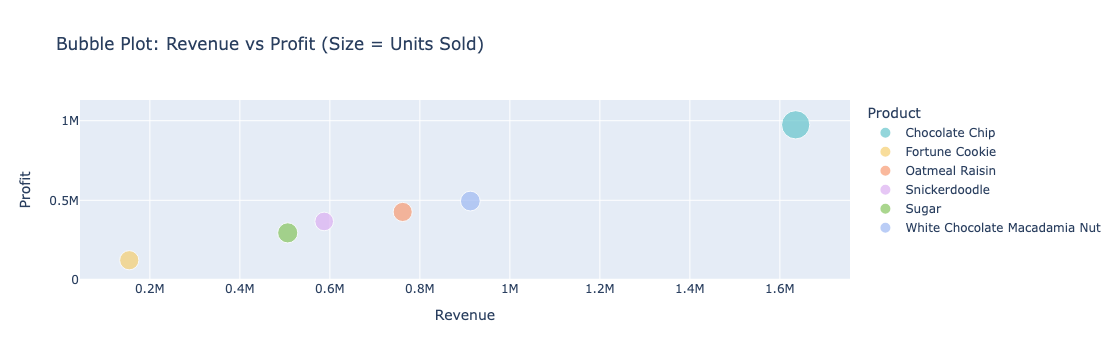

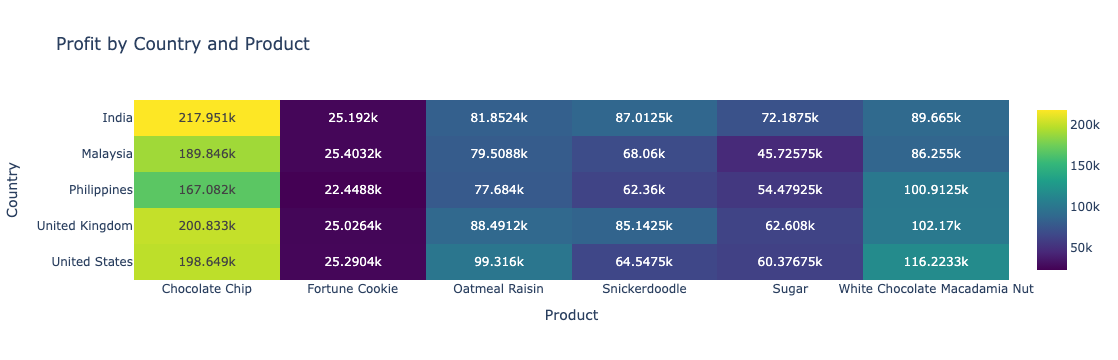

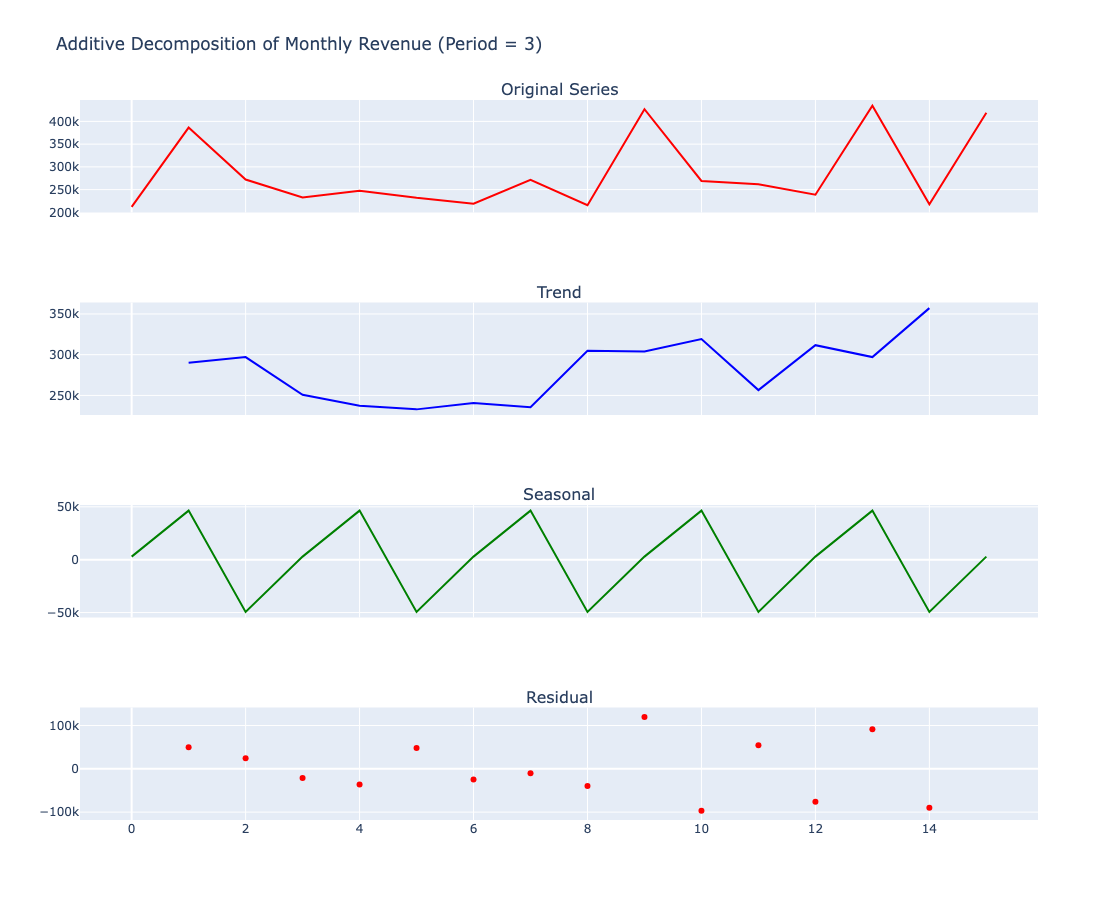

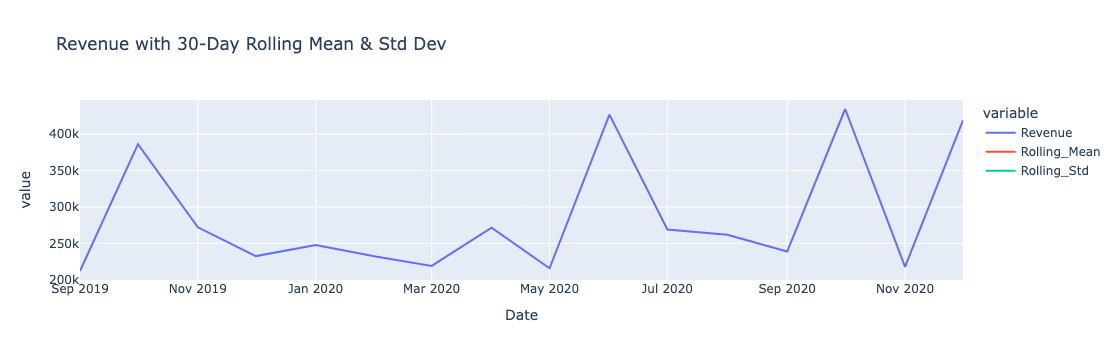

In [9]:
# Initialize Data Loader
loader = DataLoader()

# Load Data
data = loader.load_data(input_data = '../data/sales_data.csv')

# Initialize Data Inspection
processor = DataInspection(input_data = data)

# Describe data
description = processor.data_description()

# Metadata
metadata = processor.data_info()

# Get Column Names
column_names = processor.col_names()

# Get Dataset Shape
rows_columns = processor.data_shape()

# Find Empty Data
missing = processor.find_null()

format_date = processor.change_date_format()

sorted_data = processor.sort_data()

find_duplicates = processor.find_duplicate()
remove_duplicate = processor.remove_duplicates()

check_revenue = processor.check_outliers(column_name = 'Revenue')
check_units_sold = processor.check_outliers(column_name = 'Units Sold')
check_profit = processor.check_outliers(column_name = 'Profit')
check_cost = processor.check_outliers(column_name = 'Cost')

handle_revenue = processor.handle_outliers(window = 10, column_name = 'Revenue')
handle_units_sold = processor.handle_outliers(window = 10, column_name = 'Units Sold')
handle_profit = processor.handle_outliers(window = 10, column_name = 'Profit')
handle_cost = processor.handle_outliers(window = 10, column_name = 'Cost')

processed_data = handle_cost


eda = ExploratoryDataAnalysis(input_data = processed_data)
revenue_sum = eda.total_revenue()
avg = eda.average_revenue()
profit = eda.profit_margin()
units = eda.total_units()

# eda.top_3_countries()
# eda.top_3_products()
# eda.barplot_total_sale_by_column(column_name = 'Country')
# eda.barplot_total_sale_by_column(column_name = 'Product')
# eda.pieplot_for_product_sale()
# eda.groupedbar_product_over_country()
# eda.sales_trend_per_product()
eda.simple_bubble_plot()
eda.heatmap_for_product_profit()
eda.decompose_revenue()


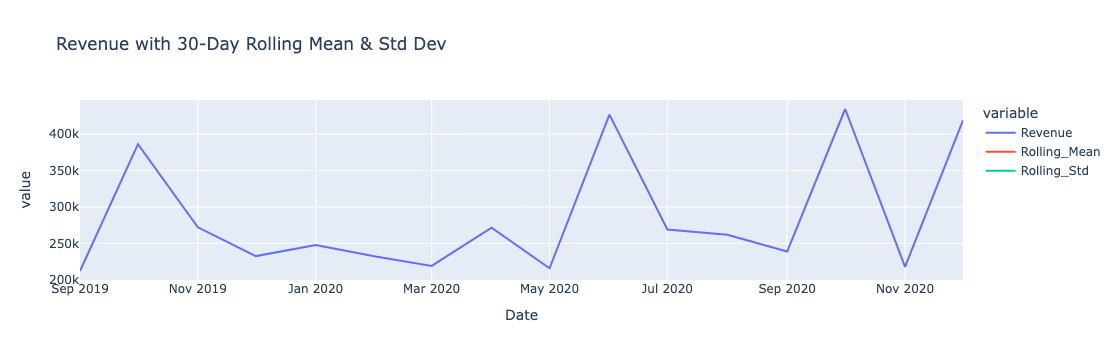

In [10]:
eda.rolling_plot(window = 30)